Loading building footprints...
CRS: EPSG:4326
Loaded 86977 buildings in your Khayelitsha AOI
Columns available: ['OBJECTID', 'DATA_SRC', 'ACQS_PRD', 'ACQS_MTHD', 'BLD_HGHT', 'Shape_Length', 'Shape_Area', 'geometry']


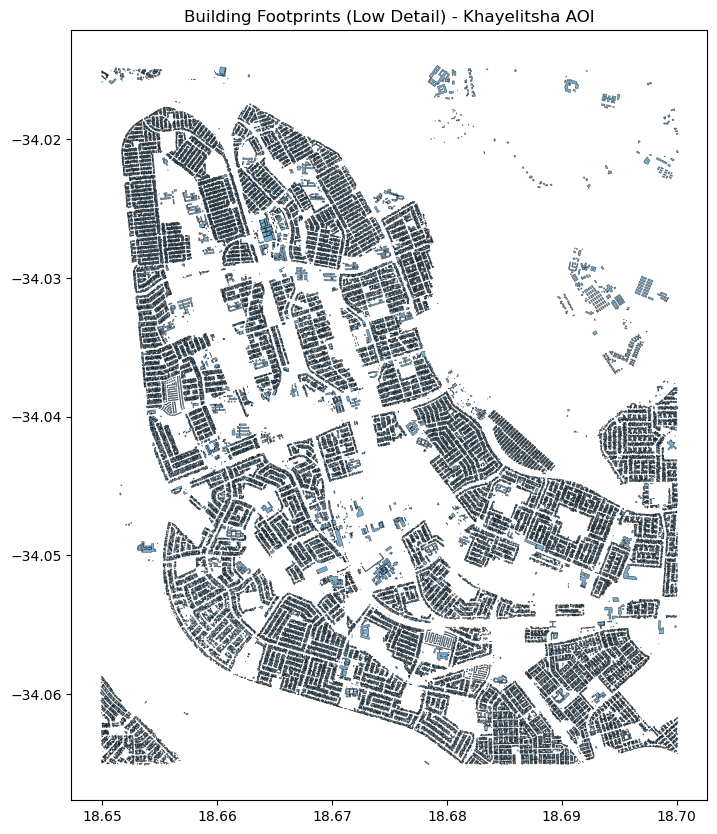

In [2]:
# Building Footprints

import geopandas as gpd
from shapely.geometry import box
import matplotlib.pyplot as plt

# Define your AOI (Khayelitsha 5km x 5km)
bbox = [18.65, -34.065, 18.70, -34.015]  # minx, miny, maxx, maxy
aoi = box(*bbox)

# Load 
print("Loading building footprints...")
buildings_full = gpd.read_file(r'I:\GEO DATA ANALYSIS\capetown_geo\2D_Building_Footprints_Low_Detail.geojson')

# Reproject
print("CRS:", buildings_full.crs)

# Clip to your AOI
buildings = buildings_full[buildings_full.intersects(aoi)].copy()

print(f"Loaded {len(buildings)} buildings in your Khayelitsha AOI")
print("Columns available:", buildings.columns.tolist())

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
buildings.plot(ax=ax, alpha=0.6, edgecolor='black', linewidth=0.4)
ax.set_title("Building Footprints (Low Detail) - Khayelitsha AOI")
plt.show()

Loading zoning layer...
Zoning CRS: EPSG:4326
Loaded 44546 zoning polygons in your AOI
Zoning columns: ['OBJECTID', 'SL_LAND_PRCL_KEY', 'SG26_CODE', 'LU_IZNG_CD_KEY', 'INT_ZONE_VALUE', 'INT_ZONE_CODE', 'INT_ZONE_DESC', 'LU_LGL_STS_KEY', 'Shape__Area', 'Shape__Length', 'geometry']

Unique zoning types: Check column names for zoning code


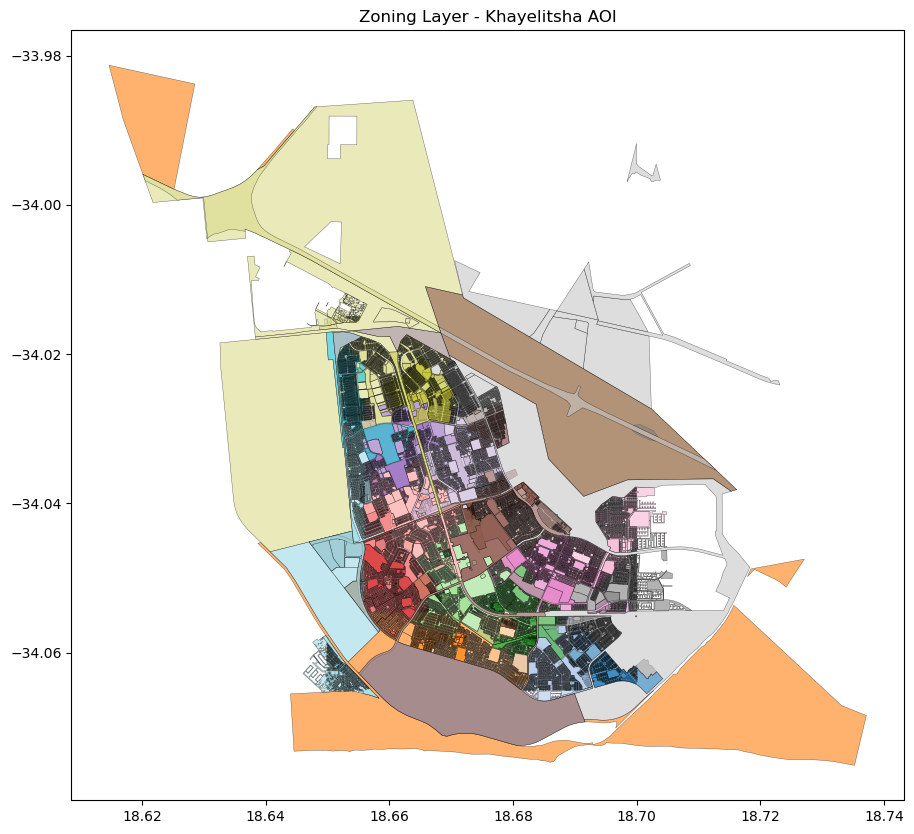

In [3]:
# Zoning layer 

import geopandas as gpd
from shapely.geometry import box
import matplotlib.pyplot as plt


bbox = [18.65, -34.065, 18.70, -34.015]
aoi = box(*bbox)

# Load the zoning file
print("Loading zoning layer...")
zoning_full = gpd.read_file(r'I:\GEO DATA ANALYSIS\capetown_geo\Zoning.geojson')  

print("Zoning CRS:", zoning_full.crs)

# Clip to AOI
zoning = zoning_full[zoning_full.intersects(aoi)].copy()

print(f"Loaded {len(zoning)} zoning polygons in your AOI")
print("Zoning columns:", zoning.columns.tolist())
print("\nUnique zoning types:", zoning['ZONING'].unique() if 'ZONING' in zoning.columns else "Check column names for zoning code")

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
zoning.plot(ax=ax, column='ZONING' if 'ZONING' in zoning.columns else None, 
            legend=True, alpha=0.6, edgecolor='black', linewidth=0.3, cmap='tab20')
ax.set_title("Zoning Layer - Khayelitsha AOI")
plt.show()

In [5]:
# Inspect

import geopandas as gpd


zoning = zoning

print("Unique INT_ZONE_DESC values (most important for us):")
print(zoning['INT_ZONE_DESC'].value_counts().head(20))
print("\nUnique INT_ZONE_CODE values:")
print(zoning['INT_ZONE_CODE'].unique()[:30])

print("\nSample rows:")
print(zoning[['INT_ZONE_DESC', 'INT_ZONE_CODE', 'LU_IZNG_CD_KEY']].head(10))

Unique INT_ZONE_DESC values (most important for us):
INT_ZONE_DESC
Single Residential 2 : Incremental Housing      41367
Single Residential 1 : Conventional Housing      1206
Open Space 2 : Public Open Space                  375
General Residential 3                             241
Community 1 : Local                               235
Transport 2 : Public Road and Public Parking      216
Utility                                           186
General Business 4                                164
Community 2 : Regional                            148
General Industrial 2                              148
General Residential 1 : Group Housing             128
Limited Use Zone                                   43
General Business 1                                 13
General Residential 4                              12
Agricultural                                       10
Open Space 3: Special Open Space                    7
Transport 1 : Transport Use                         6
Mixed Use 1    

In [8]:
# Get Stats

import geopandas as gpd
from shapely.geometry import box
import matplotlib.pyplot as plt


# Load 
buildings = buildings
zoning = zoning

# Reproject To UTM 34S
buildings = buildings.to_crs("EPSG:32734")
zoning   = zoning.to_crs("EPSG:32734")

print("Reprojected to EPSG:32734 (UTM Zone 34S)")
print(f"Buildings in AOI: {len(buildings)}")
print(f"Zoning in AOI: {len(zoning)}")

# Calculate building areas in square meters
buildings['area_m2'] = buildings.geometry.area
print("\nBuilding area stats (m²):")
print(buildings['area_m2'].describe())

# Save clipped and reprojected versions
buildings.to_file("buildings_khayelitsha_utm34.geojson", driver="GeoJSON")
zoning.to_file("zoning_khayelitsha_utm34.geojson", driver="GeoJSON")

print("\nSaved clipped & reprojected files")

Reprojected to EPSG:32734 (UTM Zone 34S)
Buildings in AOI: 86977
Zoning in AOI: 44546

Building area stats (m²):
count    86977.000000
mean        39.217130
std         83.941571
min          3.060811
25%         12.559060
50%         29.146577
75%         48.300047
max       7772.136768
Name: area_m2, dtype: float64

Saved clipped & reprojected files
